In [15]:
# وارد کردن کتابخانه‌ها
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as pt
from scipy import stats as st

# خواندن دیتاست تمیزشده
df = pd.read_csv("cleaned_covid_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

print("Size:", df.shape)

# خواندن فایل‌ به صورت بخش‌های 100 هزار ردیفی
for chunk in pd.read_csv("cleaned_covid_data.csv", chunksize=100000):
    print(len(chunk))

Size: (35041, 10)
35041


In [16]:
# آمار توصیفی

numeric_cols = [
    "Confirmed",
    "Deaths",
    "Recovered",
    "Active"
]

descriptive_stats = df[numeric_cols].describe()

print("آمار توصیفی متغیرهای اصلی:")
print(descriptive_stats)

آمار توصیفی متغیرهای اصلی:
          Confirmed         Deaths     Recovered        Active
count  3.504100e+04   35041.000000  3.504100e+04  3.504100e+04
mean   2.351692e+04    1227.798493  1.103168e+04  1.125744e+04
std    1.500045e+05    7423.438095  6.459747e+04  8.992780e+04
min    0.000000e+00       0.000000  0.000000e+00  0.000000e+00
25%    1.000000e+00       0.000000  0.000000e+00  0.000000e+00
50%    2.460000e+02       4.000000  3.300000e+01  8.400000e+01
75%    3.623000e+03      78.000000  1.279000e+03  1.454000e+03
max    4.290259e+06  148011.000000  1.846641e+06  2.816444e+06


In [17]:
# محاسبه میانگین، میانه و انحراف معیار

summary = pd.DataFrame({
    "Mean": df[numeric_cols].mean(),
    "Median": df[numeric_cols].median(),
    "Standard Deviation": df[numeric_cols].std()
})

print(summary)

                   Mean  Median  Standard Deviation
Confirmed  23516.923661   246.0       150004.526073
Deaths      1227.798493     4.0         7423.438095
Recovered  11031.684570    33.0        64597.471830
Active     11257.440598    84.0        89927.796280


In [18]:
# بررسی همبستگی بین Confirmed و Deaths

correlation = df["Confirmed"].corr(
    df["Deaths"],
    method="spearman"
)

print("correlation Between Confirmed and Deaths:",
      round(correlation, 4))

correlation Between Confirmed and Deaths: 0.939


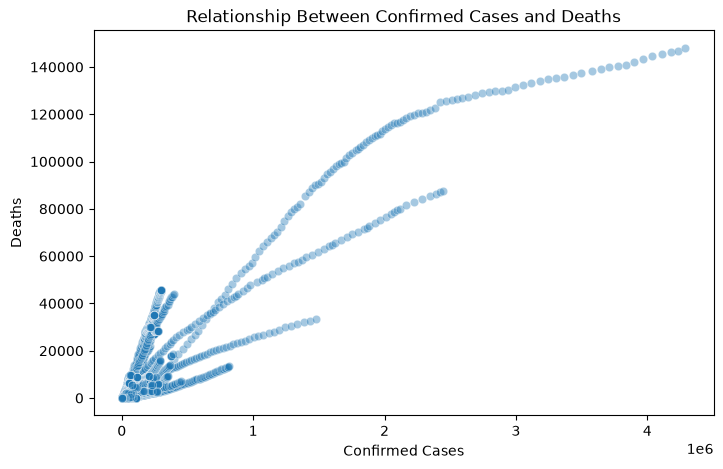

In [19]:
# نمودار رابطه Confirmed و Deaths

pt.figure(figsize=(8, 5))

sb.scatterplot(
    data=df,
    x="Confirmed",
    y="Deaths",
    alpha=0.4
)

pt.title("Relationship Between Confirmed Cases and Deaths")
pt.xlabel("Confirmed Cases")
pt.ylabel("Deaths")

pt.show()

In [20]:
# Percentiles

percentiles = df[numeric_cols].quantile([0.25, 0.50, 0.75])

print("Percentiles:")
print(percentiles)

Percentiles:
      Confirmed  Deaths  Recovered  Active
0.25        1.0     0.0        0.0     0.0
0.50      246.0     4.0       33.0    84.0
0.75     3623.0    78.0     1279.0  1454.0


In [21]:
# H0: میانگین CFR در اروپا و آمریکا برابر است
# H1: میانگین CFR در اروپا و آمریکا برابر نیست

last_date = df["Date"].max()
last = df[df["Date"] == last_date].copy()

last["CFR"] = (last["Deaths"] / last["Confirmed"]) * 100

# حذف کشورهایی با تعداد Confirmed کمتر از 100
last = last[last["Confirmed"] >= 100]

europe = last[last["WHO Region"] == "Europe"]["CFR"]
americas = last[last["WHO Region"] == "Americas"]["CFR"]

# Welch's t-test
t_stat, p_val = st.ttest_ind(
    europe,
    americas,
    equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_val)

# 95% Confidence Interval برای میانگین CFR
global_cfr = last["CFR"]

mean_cfr = global_cfr.mean()
sem_cfr = st.sem(global_cfr)

ci = st.t.interval(
    0.95,
    len(global_cfr) - 1,
    loc=mean_cfr,
    scale=sem_cfr
)

print("Mean CFR:", mean_cfr)
print("95% Confidence Interval:", ci)

t-statistic: 1.2593891812983011
p-value: 0.2116534890334024
Mean CFR: 3.1917803547538326
95% Confidence Interval: (np.float64(2.667403366838209), np.float64(3.7161573426694563))


In [22]:
# جمع‌بندی تحلیل آماری

print(" --- analysis Result --- ")
print("1. Mean، Median and Standard Deviation")
print("2. correlation")
print("3. Percentiles")
print("4. Hypothesis Test")
print("5. Confidence Interval")

 --- analysis Result --- 
1. Mean، Median and Standard Deviation
2. correlation
3. Percentiles
4. Hypothesis Test
5. Confidence Interval
